In [18]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg
import ast
import colorsys

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
MIX_COLOR = '#C07B7E'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [19]:
stim_df = pd.read_csv(os.path.join('..','..','Source Data Files',"Figure 2j.csv"))

In [20]:
stim_df

,Unnamed: 0,session,clust,accuracy,NCR_ratio,learning_phase,animal
0,0,BS_108_1_AC.pickle,[14],0.551433,0.000000,pre_expert,BS_108_1_AC
1,1,BS_108_1_AC.pickle,"[8, 9, 34, 35]",0.837250,0.000000,pre_expert,BS_108_1_AC
2,2,BS_108_1_AC.pickle,"[8, 9, 14, 34]",0.853713,0.000000,pre_expert,BS_108_1_AC
3,3,BS_108_1_AC.pickle,"[2, 8, 9, 34, 35]",0.831911,0.000000,pre_expert,BS_108_1_AC
4,4,BS_108_1_AC.pickle,"[2, 8, 9, 34, 35]",0.831911,0.000000,pre_expert,BS_108_1_AC
...,...,...,...,...,...,...,...
13752,13752,DS_19_20_AC.pickle,"[7, 14]",0.907200,0.000000,post_expert,DS_19_20_AC
13753,13753,DS_19_20_AC.pickle,"[7, 8]",0.881400,0.500000,post_expert,DS_19_20_AC
13754,13754,DS_19_20_AC.pickle,[7],0.809600,0.000000,post_expert,DS_19_20_AC
13755,13755,DS_19_20_AC.pickle,[8],0.828000,1.000000,post_expert,DS_19_20_AC


6.0


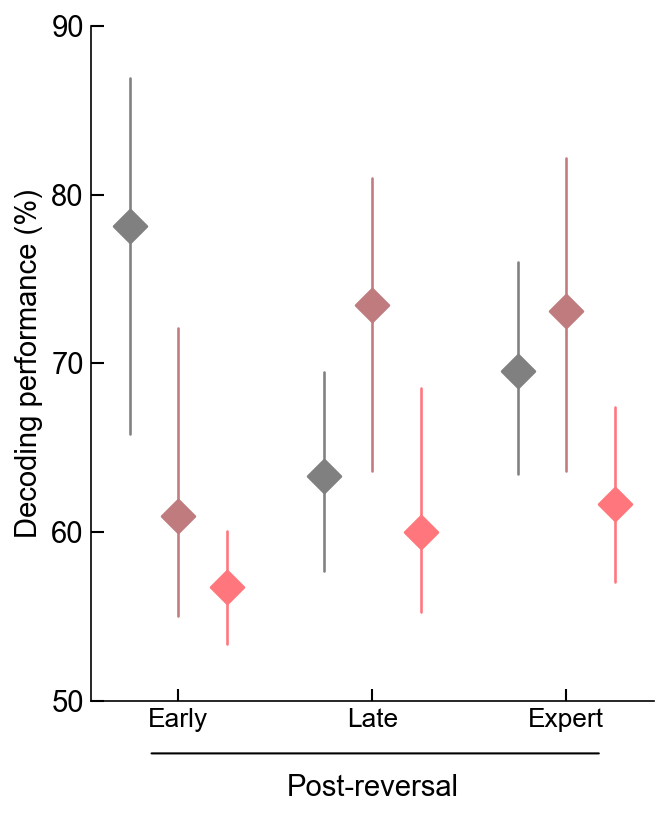

In [21]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax
def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax
fig,ax = make_axis_size(3.75, 4.5, left=.3, bottom=.3, right=0, top=0)
switch_offset = 1

#Firing rate modulation graphs
NCR_COLORS = [CR_COLOR,MIX_COLOR,NCR_COLOR]
NCR_labels = ['CR','Mixed','NCR']
size=5
chosen_phases = ['pre_early','pre_late','pre_expert','post_early','post_late','post_expert']
bins = pd.IntervalIndex.from_tuples([(-0.01, 0.31), (0.49, 0.71), (0.79, 100.01)])

data = []
for chosen_phase in chosen_phases[3:]:
    stim_df_com = stim_df[(stim_df.learning_phase==chosen_phase)]
    stim_df_com['NCR_ratio_binned'], _= pd.cut(stim_df_com['NCR_ratio'], bins=bins, retbins = True)
    clusters = stim_df_com['clust'].apply(ast.literal_eval)
    stim_df_ensemble_com = stim_df_com[[len(x)>1 for x in clusters]]
    # stim_df_ensemble_com = stim_df_com
    acc_temp = stim_df_ensemble_com[stim_df_ensemble_com['NCR_ratio_binned']==bins[0]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com[stim_df_ensemble_com['NCR_ratio_binned']==bins[1]]['accuracy'].tolist()
    data.append(acc_temp)
    acc_temp = stim_df_ensemble_com[stim_df_ensemble_com['NCR_ratio_binned']==bins[2]]['accuracy'].tolist()
    data.append(acc_temp)
labels = ['Early','Late','Expert']
numCon = 3
X = [np.ones(len(l))*idx for idx,l in enumerate(data)]

_,Y = ilep.violin(np.concatenate(X),np.concatenate(data),width=0.25)
X,_ = ilep.violin(np.concatenate(X),np.log10(np.concatenate(data)),width=0.25)
colors = NCR_CR_cmap((Y-1)/5)
x_list_plot = [0,1,2,3+switch_offset,4+switch_offset,5+switch_offset,6+2*switch_offset, 7+2*switch_offset, 8+2*switch_offset]
#Plot summary
for idx,column in enumerate(data):    
    eye_color=GOOD_GREY
    
    r,g,b = mpl.colors.to_rgb(eye_color)
    h,l,s = colorsys.rgb_to_hls(r,g,b)
    border_color=colorsys.hls_to_rgb(h,l,s)
    border_color = 'k'
    summary_size=125
    summary_width=1.25
    
    X = np.ones(len(column))*(x_list_plot[idx])

    _,Y = ilep.violin(X,column,width=0.5,minjitter=0.05)
    X,_ = ilep.violin(X,np.log10(column),width=0.5,minjitter=0.05)
    colors = NCR_CR_cmap((Y-1)/5)

    mean = np.mean(column)
    sem = np.std(column, ddof=1) / np.sqrt(np.size(column))
    Q1, median, Q3 = (np.percentile(column, q) for q in [25, 50, 75])
    
    ax.scatter([x_list_plot[idx]], [median], ec=NCR_COLORS[idx%3],fc= NCR_COLORS[idx%3], s=summary_size,lw=summary_width, zorder=10,marker='D')
    ax.plot([x_list_plot[idx], x_list_plot[idx]], [Q1, Q3], c=NCR_COLORS[idx%3], lw=summary_width, zorder=9, solid_capstyle='round')

xtick_pos_pre = ax.get_xticks()[4]
print(xtick_pos_pre)
ax.set_ylim([0.5,0.90])
ax.set_yticks([0.5,0.6,0.7,0.8,0.9])
ax.set_yticklabels(['50','60','70','80','90'])
ylab = ax.set_ylabel('Decoding performance (%)')

ax.set_xlim([x_list_plot[0]-0.8,x_list_plot[-1]+0.8])
ax.set_xticks([x_list_plot[1],x_list_plot[4],x_list_plot[7]])
ax.set_xticklabels(labels)
ax.set_xlim(ax.get_xlim())
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2.5*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre-1, Yval, 'Post-reversal', ha='center', va='bottom', fontsize=stdfont,color='k')
ax.annotate('', xy=(0.1, -stdyfrac*1.3), xycoords='axes fraction', xytext=(0.91, -stdyfrac*1.3),arrowprops=dict(arrowstyle='-', color='black'))
    
ax.fill_between(ax.get_xlim(),[ax.get_ylim()[0]]*2,[ax.get_ylim()[1]]*2,color='white',alpha=0.5,zorder=-5)
artists = [ylab,t1]
ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
# fig.savefig(os.path.join('..','..','Figures','Figure 2i.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [6]:
# Significiance Test
bins = pd.IntervalIndex.from_tuples([(-0.01, 0.31), (0.49, 0.71), (0.79, 100.01)])
stim_df_com = stim_df
stim_df_com['NCR_ratio_binned'], bins= pd.cut(stim_df_com['NCR_ratio'], bins=bins, retbins = True)
clusters = stim_df_com['clust'].apply(ast.literal_eval)
stim_df_ensemble_com = stim_df_com[[len(x)>1 for x in clusters]]
stim_df_ensemble_com = stim_df_ensemble_com.dropna()


stim_df_ensemble_com = stim_df_ensemble_com[stim_df_ensemble_com['learning_phase'].str.contains("post")]
### Anova ###
anova = pg.anova(data=stim_df_ensemble_com, dv='accuracy', between=['NCR_ratio_binned','learning_phase'], detailed=True)
print(anova)

### Create and print results ###
pairwise_mwu = pg.pairwise_tests(data=stim_df_ensemble_com, dv='accuracy', between=['learning_phase','NCR_ratio_binned'], padjust="fdr_bh", parametric=False )
pairwise_mwu['A'] = pairwise_mwu['A'].astype('string')
print(pairwise_mwu[pairwise_mwu["Contrast"] == "learning_phase * NCR_ratio_binned" ][["learning_phase","A", "B", "p_unc", "p_corr", "hedges"]])
pairwise_mwu = pairwise_mwu[(pairwise_mwu["Contrast"] == "learning_phase * NCR_ratio_binned") ][["learning_phase","A", "B", "p_unc", "p_corr", "hedges"]]

                              Source         SS      DF        MS           F  \
0                   NCR_ratio_binned  13.657326     2.0  6.828663  573.918291   
1                     learning_phase   2.193680     2.0  1.096840   92.184468   
2  NCR_ratio_binned * learning_phase   7.134192     4.0  1.783548  149.899149   
3                           Residual  69.688456  5857.0  0.011898         NaN   

           p_unc       np2  
0  2.448089e-228  0.163863  
1   3.819420e-40  0.030518  
2  3.001173e-122  0.092866  
3            NaN       NaN  
   learning_phase              A               B          p_unc  \
6      post_early  (-0.01, 0.31]    (0.49, 0.71]   2.255308e-92   
7      post_early  (-0.01, 0.31]  (0.79, 100.01]  1.507420e-110   
8      post_early   (0.49, 0.71]  (0.79, 100.01]   3.902671e-22   
9     post_expert  (-0.01, 0.31]    (0.49, 0.71]   6.091446e-03   
10    post_expert  (-0.01, 0.31]  (0.79, 100.01]   5.256517e-13   
11    post_expert   (0.49, 0.71]  (0.79, 100.01